# Land-Use Data Preparation

This notebook explores and cleans OpenStreetMap land-use polygons and maps relevant land-use types to the building classification taxonomy. 

**Input**
- OpenStreetMap land-use polygons for Germany.
- Building data with Stage 1 classifications.

**Output**
- Cleaned and mapped land-use polygons.


In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys



ROOT_DIR = '/fast/home/o-olajuyigbe/osm_project'
DATA_DIR = os.path.join(ROOT_DIR, 'data')
SCRIPTS   = os.path.join(ROOT_DIR, 'scripts')

BUILDING_FILE = os.path.join(DATA_DIR, 'processed', 'germany_buildings_classified_stage1.parquet')
LANDUSE_FILE = os.path.join(DATA_DIR, 'interim', 'germany_landuse.parquet')
POI_FILE = os.path.join(DATA_DIR, 'interim', 'germany_poi.parquet')

if SCRIPTS not in sys.path:
    sys.path.insert(0, SCRIPTS)


In [ ]:
print("Loading Germany Landuse Data...")

# Load Parquet files
gdf_bldg = gpd.read_parquet(BUILDING_FILE)
gdf_landuse = gpd.read_parquet(LANDUSE_FILE)

print("Data loaded successfully!")

Loading Germany Landuse Data...
Data loaded successfully!


In [34]:
FAKE_NULLS = {'nan', 'NaN', 'None', 'none', '', ' ', 'NULL', 'null'}

def replace_fake_nulls(gdf, name='dataset'):
    replaced = 0
    for col in gdf.select_dtypes(include=['object']).columns:
        if col == 'geometry':
            continue
        mask = gdf[col].isin(FAKE_NULLS)
        n = mask.sum()
        if n > 0:
            gdf.loc[mask, col] = np.nan
            replaced += n
    print(f'[{name}] Replaced {replaced:,} fake-null strings with np.nan')
    return gdf

gdf_landuse = replace_fake_nulls(gdf_landuse, 'landuse')


[landuse] Replaced 129,099,657 fake-null strings with np.nan


In [35]:
VALID_GEOM_TYPES = {'Polygon', 'MultiPolygon'}

print('Initial geometry types:')
print(gdf_landuse.geometry.geom_type.value_counts().to_string())

before = len(gdf_landuse)
gdf_landuse = gdf_landuse[gdf_landuse.geometry.geom_type.isin(VALID_GEOM_TYPES)].copy()
after_geo_filtering = len(gdf_landuse)

print(f'Rows before : {before:,}')
print(f'Rows after  : {after_geo_filtering:,}')
print(f'Dropped     : {before - after_geo_filtering:,}  ({(before-after_geo_filtering)/before*100:.5f}%)')
print()
print('Remaining geometry types:')
print(gdf_landuse.geometry.geom_type.value_counts().to_string())


Initial geometry types:
Polygon            4940324
MultiPolygon         25509
Point                 1971
MultiLineString        210
LineString             111
Rows before : 4,968,125
Rows after  : 4,965,833
Dropped     : 2,292  (0.04613%)

Remaining geometry types:
Polygon         4940324
MultiPolygon      25509


In [36]:
invalid_before = (~gdf_landuse.geometry.is_valid).sum()
empty_before   = gdf_landuse.geometry.is_empty.sum()
print(f'Invalid geometries before fix : {invalid_before:,}')
print(f'Empty geometries before fix   : {empty_before:,}')
print()
print('Applying .buffer(0) to invalid geometries...')

broken_indices = gdf_landuse[~gdf_landuse.geometry.is_valid].index

# Fix only invalid ones (buffer is expensive at 38 M rows — apply selectively)
invalid_mask = ~gdf_landuse.geometry.is_valid
gdf_landuse.loc[invalid_mask, 'geometry'] = gdf_landuse.loc[invalid_mask, 'geometry'].buffer(0)

# Drop any that are still invalid or now empty after buffering
still_invalid = ~gdf_landuse.geometry.is_valid
still_empty   = gdf_landuse.geometry.is_empty
drop_mask     = still_invalid | still_empty
n_drop        = drop_mask.sum()
gdf_landuse = gdf_landuse[~drop_mask].copy()

after_invalid_fix = len(gdf_landuse)

print(f'Fixed with buffer(0)          : {invalid_before - n_drop:,}')
print(f'Dropped (unfixable/empty)     : {n_drop:,}')
print(f'Remaining invalid             : {(~gdf_landuse.geometry.is_valid).sum():,}  ← should be 0')
print(f'Rows remaining                : {after_invalid_fix:,}')


Invalid geometries before fix : 1,834
Empty geometries before fix   : 0

Applying .buffer(0) to invalid geometries...
Fixed with buffer(0)          : 1,794
Dropped (unfixable/empty)     : 40
Remaining invalid             : 0  ← should be 0
Rows remaining                : 4,965,793


In [37]:
# Inspect OSM ID column for uniqueness and completeness, as it's critical for database integrity

TOTAL = len(gdf_landuse)
ID_COL = 'id'
print()
print('OSM ID ANALYSIS:')
print(f'  Total rows        : {TOTAL:,}')
print(f'  Non-null IDs      : {gdf_landuse[ID_COL].notna().sum():,}')
print(f'  Unique IDs        : {gdf_landuse[ID_COL].nunique():,}')
print(f'  Duplicate IDs     : {TOTAL - gdf_landuse[ID_COL].nunique():,}')
print(f'  Sample values     : {gdf_landuse[ID_COL].head(5).tolist()}')

if gdf_landuse[ID_COL].nunique() == TOTAL:
    print()
    print('RESULT: All IDs unique. The database primary key is intact.')
else:
    dupes = TOTAL - gdf_landuse[ID_COL].nunique()
    print(f'\nWARNING: {dupes:,} duplicate IDs found.')
    print('This must be investigated before building the database.')

dupes = gdf_landuse[gdf_landuse[ID_COL].duplicated(keep=False)].sort_values(by=ID_COL)
dupes[['id', 'geometry', 'landuse', 'osm_type']].head(6)


OSM ID ANALYSIS:
  Total rows        : 4,965,793
  Non-null IDs      : 4,965,793
  Unique IDs        : 4,965,756
  Duplicate IDs     : 37
  Sample values     : [3220314, 3401793, 3427734, 3453426, 3619419]

This must be investigated before building the database.


,id,geometry,landuse,osm_type
4526,7798590,"POLYGON ((8.07905 52.29351, 8.07908 52.29343, ...",forest,way
4823617,7798590,"MULTIPOLYGON (((10.4253 50.06956, 10.42539 50....",forest,relation
341203,96248805,"POLYGON ((9.2026 49.05505, 9.20187 49.05491, 9...",orchard,way
4888452,96248805,"MULTIPOLYGON (((8.63356 49.14653, 8.63416 49.1...",meadow,relation
4825249,100064220,"POLYGON ((12.15555 50.10419, 12.15583 50.10418...",farmland,relation
372639,100064220,"POLYGON ((7.25431 52.63963, 7.2543 52.63972, 7...",forest,way


In [38]:
print("Unique duplicate IDs:", dupes[ID_COL].nunique())
print("Rows involved:", len(dupes))

print("\nOSM types:")
print(dupes["osm_type"].value_counts())

print("\nGeometry equality check:")
print((dupes.groupby(ID_COL)["geometry"]
       .nunique()
       .value_counts()))

Unique duplicate IDs: 37
Rows involved: 74

OSM types:
osm_type
way         37
relation    37
Name: count, dtype: int64

Geometry equality check:
geometry
2    37
Name: count, dtype: int64


Inspect relations, dupicate ids only appear where there are relations

In [39]:
gdf_landuse['osm_type'].value_counts()

osm_type
way         4820443
relation     145350
Name: count, dtype: int64

In [40]:
gdf_landuse[gdf_landuse.osm_type == 'relation'][['id', 'landuse', 'geometry']].sample(30)

,id,landuse,geometry
4965768,110990529078,meadow,"POLYGON ((13.30255 51.4445, 13.30277 51.44371,..."
4824017,196178198,forest,"POLYGON ((10.17884 52.46718, 10.17829 52.46716..."
4885287,1523779724,meadow,"POLYGON ((8.21305 47.85901, 8.21286 47.85882, ..."
4928055,62886754714,forest,"POLYGON ((7.94828 52.12474, 7.94781 52.12428, ..."
4869132,13747060425,forest,"POLYGON ((10.39299 52.65007, 10.39442 52.6503,..."
4944875,59518790220,farmland,"POLYGON ((9.78204 52.27028, 9.78099 52.27007, ..."
4859385,16708959486,farmland,"POLYGON ((7.59557 48.08286, 7.59561 48.08272, ..."
4880400,5097311976,meadow,"POLYGON ((7.44194 49.21716, 7.44393 49.21864, ..."
4896822,2703151390,meadow,"MULTIPOLYGON (((10.05618 50.73303, 10.05628 50..."
4922507,51261748001,forest,"POLYGON ((11.30813 49.75652, 11.30853 49.75646..."


In [41]:
print("--- Cleaning Corrupted OSM Types ---")

initial_count = len(gdf_landuse)
relations_count = (gdf_landuse['osm_type'] == 'relation').sum()

print(f"Total rows before cleaning: {initial_count:,}")
print(f"Identified {relations_count:,} 'relation' types for removal.")

# Keep only rows where osm_type is NOT 'relation'
gdf_landuse = gdf_landuse[gdf_landuse['osm_type'] != 'relation'].copy()

after_relation_drop = len(gdf_landuse)

print(f"Dataset size after dropping relations: {after_relation_drop:,}")

--- Cleaning Corrupted OSM Types ---
Total rows before cleaning: 4,965,793
Identified 145,350 'relation' types for removal.
Dataset size after dropping relations: 4,820,443


In [ ]:
print("── Checking for Duplicates ───────────────────────")

# Find all rows where the composite 'id' is duplicated 
duped_uid_mask = gdf_landuse['id'].duplicated(keep=False)

print(f"Rows with duplicated id : {duped_uid_mask.sum():,}")

if duped_uid_mask.sum() > 0:
    print('\nArtefact rows (UID Collisions):')
    # Display the problematic rows to inspect why they have the same UID
    display(gdf_landuse[duped_uid_mask][['id', 'osm_type', 'landuse', 'geometry']].head(20))


── Checking for Duplicates ───────────────────────
Rows with duplicated id : 0


/tmp/ipykernel_1590698/3745071417.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=stages, y=counts, palette="crest", edgecolor="black")


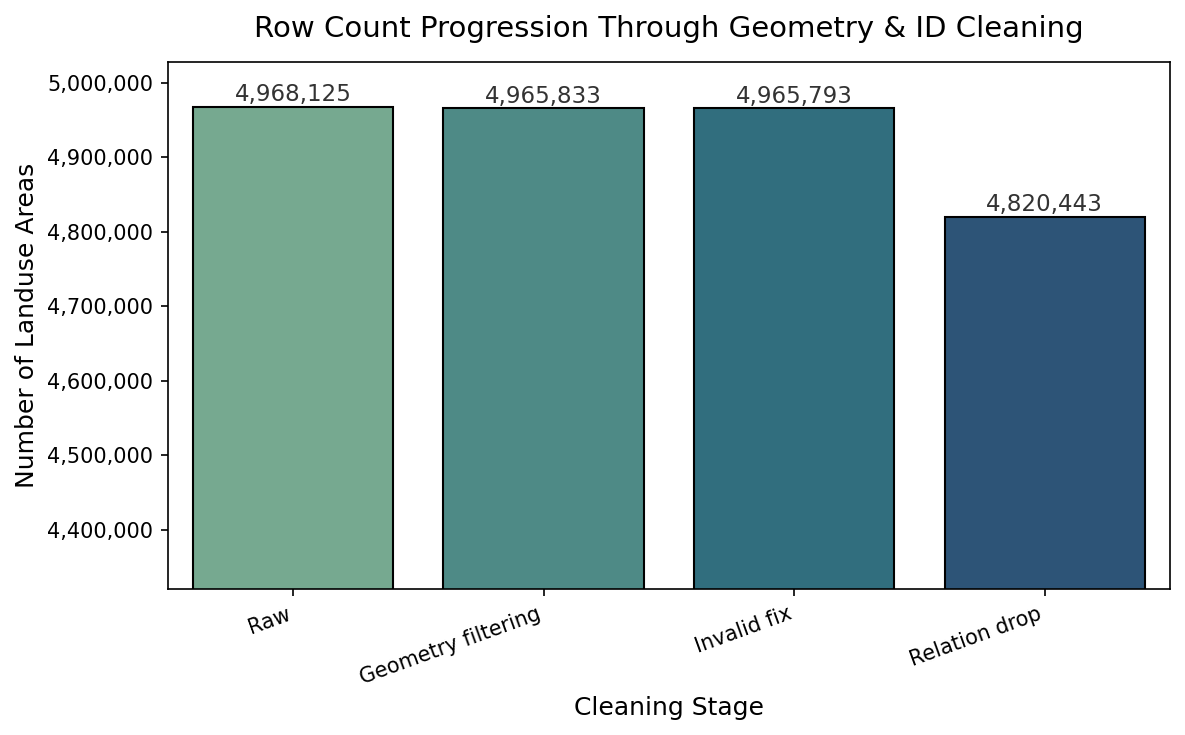

In [43]:
stages = ['Raw', 'Geometry filtering', 'Invalid fix',
    'Relation drop']

counts = [before, after_geo_filtering, after_invalid_fix, len(gdf_landuse)]

# Compute zoom range
min_val = min(counts)
max_val = max(counts)

# Add margin for readability
lower = min_val - 500000
upper = max_val + 60000

plt.figure(figsize=(8, 5), dpi=150)

ax = sns.barplot(x=stages, y=counts, palette="crest", edgecolor="black")

plt.title("Row Count Progression Through Geometry & ID Cleaning", fontsize=14, pad=12)
plt.ylabel("Number of Landuse Areas", fontsize=12)
plt.xlabel("Cleaning Stage", fontsize=12)
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.ylim(lower, upper)
plt.xticks(rotation=20, ha='right')

# Add labels above bars
for i, c in enumerate(counts):
    ax.text(i, c + (upper - lower) * 0.01, f"{c:,}", ha="center", fontsize=11, color="#333")

plt.tight_layout()
plt.show()


In [44]:
gdf_landuse.to_parquet(os.path.join(DATA_DIR, 'interim', 'germany_landuse_cleaned.parquet'), index=False)

In [2]:
test = gpd.read_parquet(os.path.join(DATA_DIR, 'interim', 'germany_landuse_cleaned.parquet'))

In [3]:
test.head(5)

,visible,tags,changeset,timestamp,version,lon,lat,id,allotments,basin,...,farmyard,forest,grass,greenfield,landfill,meadow,port,recreation_ground,reservoir,retail
0,None,"{""visible"":false}",NaN,1656086003,27,NaN,NaN,3220314,None,None,...,None,None,None,None,None,None,None,None,None,None
1,None,"{""visible"":false,""amenity"":""parking"",""leisure""...",NaN,1478163357,4,NaN,NaN,3401793,None,None,...,None,None,None,None,None,None,None,None,None,None
2,None,"{""visible"":false,""barrier"":""fence"",""name"":""Fri...",NaN,1627817241,9,NaN,NaN,3427734,None,None,...,None,None,None,None,None,None,None,None,None,None
3,None,"{""visible"":false,""landcover"":""grass""}",NaN,1711913366,5,NaN,NaN,3453426,None,None,...,None,None,None,None,None,paddock,None,None,None,None
4,None,"{""visible"":false}",NaN,1351144667,8,NaN,NaN,3619419,None,None,...,None,None,None,None,None,None,None,None,None,None


In [12]:
test[test['industrial'].notna()][['id', 'landuse', 'industrial']].sample(5)

,id,landuse,industrial
4098306,1186352558,industrial,scrap_yard
380956,101227493,industrial,agriculture
1996431,413191907,industrial,construction
4419865,1314497960,industrial,power
1638786,336982825,industrial,compost


In [ ]:
print("Land use types available:")
print(f"Number of unique land use types: {gdf_landuse['landuse'].nunique()}")
print(gdf_landuse['landuse'].value_counts().head(30))

print(f"\nTotal land use polygons: {len(gdf_landuse):,}")
print(f"CRS: {gdf_landuse.crs.to_string()}")

# Make sure CRS matches the buildings
print(f"Buildings CRS: {gdf_bldg.crs.to_string()}")

Land use types available:
Number of unique land use types: 362
landuse
meadow                     1184569
farmland                   1157536
grass                       736233
forest                      539078
residential                 436231
farmyard                    190714
orchard                      95877
allotments                   69834
commercial                   61174
industrial                   57771
vineyard                     55485
cemetery                     30616
highway                      23699
railway                      19496
construction                 18348
retail                       17130
basin                        16993
plant_nursery                14392
village_green                13382
garages                      11365
flowerbed                    10773
recreation_ground             9301
brownfield                    7980
quarry                        7677
greenfield                    7321
greenhouse_horticulture       5202
reservoir          

In [46]:
all_values = gdf_landuse['landuse'].value_counts()

# How many values cover 95% of polygons?
cumsum = all_values.cumsum() / all_values.sum()
n_to_cover_95 = (cumsum < 0.95).sum()
print(f"Total unique values      : {len(all_values):,}")
print(f"Values covering 95%      : {n_to_cover_95}")
print(f"Values covering 99%      : {(cumsum < 0.99).sum()}")
print(f"\nTop 50 cover this many polygons:")
print(f"{all_values.head(50).sum():,} of {len(gdf_landuse):,} ({all_values.head(50).sum()/len(gdf_landuse)*100:.1f}%)")

# How many polygons have values that appear only once?
singletons = (all_values == 1).sum()
print(f"\nSingleton values (appear once): {singletons}")
print(f"Polygons with singleton values: {singletons}")

Total unique values      : 362
Values covering 95%      : 10
Values covering 99%      : 22

Top 50 cover this many polygons:
4,818,867 of 4,820,443 (100.0%)

Singleton values (appear once): 165
Polygons with singleton values: 165


In [47]:
all_values.head(50)

landuse
meadow                     1184569
farmland                   1157536
grass                       736233
forest                      539078
residential                 436231
farmyard                    190714
orchard                      95877
allotments                   69834
commercial                   61174
industrial                   57771
vineyard                     55485
cemetery                     30616
highway                      23699
railway                      19496
construction                 18348
retail                       17130
basin                        16993
plant_nursery                14392
village_green                13382
garages                      11365
flowerbed                    10773
recreation_ground             9301
brownfield                    7980
quarry                        7677
greenfield                    7321
greenhouse_horticulture       5202
reservoir                     3641
religious                     3503
landfill    

In [48]:
# Column Inspection
# Check if the  columns have data or are mostly null
cols = gdf_landuse[[col for col in gdf_landuse.columns if gdf_landuse[col].dtype == 'object']]

# Check what values are in the columns
print("\nSample values in each column:")
for col in cols:
    if col in gdf_landuse.columns:
        non_null = gdf_landuse[col].notna().sum()
        print(f"  {col:<20}: {non_null:,} non-null)")
        print(f"  {col:<20}: {gdf_landuse[col].value_counts().head(5).to_string()}")
        print()




Sample values in each column:
  visible             : 0 non-null)
  visible             : Series([], )

  tags                : 4,820,443 non-null)
  tags                : tags
{"visible":false}                              4176482
{"visible":false,"source":"Bing"}                43750
{"visible":false,"crop":"grape"}                 42363
{"visible":false,"leaf_type":"broadleaved"}      42103
{"visible":false,"source":"bing"}                28596

  allotments          : 1,411 non-null)
  allotments          : allotments
plot                  1257
garden                 138
cottage_settlement       8
permanent_camping        4
rural                    2

  basin               : 4,193 non-null)
  basin               : basin
detention       1985
retention       1283
infiltration     767
settling          56
stormwater        19

  cemetery            : 542 non-null)
  cemetery            : cemetery
sector           252
war_cemetery     137
wood              79
burial_forest     25
colu

In [ ]:
# how many values appear only once or twice?
value_counts = gdf_landuse['landuse'].value_counts()
print(f"Total unique values     : {len(value_counts):,}")
print(f"Values appearing once   : {(value_counts == 1).sum():,}")
print(f"Values appearing < 5    : {(value_counts < 5).sum():,}")
print(f"Values appearing < 10   : {(value_counts < 10).sum():,}")
print(f"\nTop 30 cover how much?")
top30_coverage = value_counts.head(30).sum() / len(gdf_landuse) * 100
print(f"  {top30_coverage:.1f}% of all polygons")

Total unique values     : 362
Values appearing once   : 165
Values appearing < 5    : 253
Values appearing < 10   : 273

Top 30 cover how much?
  99.8% of all polygons


In [50]:
LANDUSE_MAP = {
    'residential'                       : ('residential', None),
    'cottage_settlement'                : ('residential', 'SFH'),
    'suburb'                            : ('residential', None),
    'resort'                            : ('commercial', None),
    'offices'                           : ('commercial', 'office'),
    'retail'                            : ('commercial', 'retail'),
    'commercial'                        : ('commercial', None),
    'car_sale'                          : ('commercial', 'retail'),
    'fuel'                              : ('commercial', 'retail'),
    'warehouse'                         : ('industrial', 'storage'),
    'storage'                           : ('industrial', 'storage'),
    'storage_depot'                     : ('industrial', 'storage'),
    'storage_tank'                      : ('industrial', 'storage'),
    'material_storage'                  : ('industrial', 'storage'),
    'tanker_terminal'                   : ('industrial', None),
    'industrial'                        : ('industrial', None),  # default industrial
    'quarry'                            : ('industrial', 'manufacturing'),
    'mine'                              : ('industrial', 'manufacturing'),
    'peat_cutting'                      : ('industrial', 'manufacturing'),
    'wastewater_plant'                  : ('industrial', 'utilities'),
    'water_storage'                     : ('industrial', 'utilities'),
    'power'                             : ('industrial', 'utilities'),
    'hydro'                             : ('industrial', 'utilities'),
    'military'                          : ('military', None), 
    'farmland'                          : ('agricultural', None),
    'meadow'                            : ('agricultural', None),
    'orchard'                           : ('agricultural', None),
    'farmyard'                           : ('agricultural', None),
    'plant_nursery'                     : ('agricultural', None),
    'allotments'                        : ('agricultural', None),
}

In [ ]:
# STEP 1: Map landuse to types using the LANDUSE_MAP

gdf_landuse['zone_l1'] = gdf_landuse['landuse'].map(
    {k: v[0] for k, v in LANDUSE_MAP.items()}
)
gdf_landuse['zone_l2'] = gdf_landuse['landuse'].map(
    {k: v[1] for k, v in LANDUSE_MAP.items()}
)

print(gdf_landuse['zone_l1'].value_counts(dropna=False).head(15))
print(f"\nMapped zone: {gdf_landuse['zone_l1'].notna().sum():,}")
print(f"Unmapped zone    : {gdf_landuse['zone_l1'].isna().sum():,}")

zone_l1
agricultural    2712922
NaN             1525711
residential      436234
commercial        78312
industrial        65670
military           1594
Name: count, dtype: int64

Mapped zone: 3,294,732
Unmapped zone    : 1,525,711


In [ ]:
landuse_slim = gdf_landuse[[
    'id', 'geometry', 'landuse',
    'zone_l1', 'zone_l2', 'industrial', 'tags']].copy()

# Remove zones not mapped (no zone_l1)
landuse_slim = landuse_slim[landuse_slim['zone_l1'].notna()].copy()
landuse_slim['zone_area_sqm'] = landuse_slim.to_crs(epsg=3035).geometry.area

print(f"Landuse polygons before filtering to mapped types: {len(gdf_landuse):,}")
print(f"Landuse polygons after filtering to mapped types: {len(landuse_slim):,}")
print(landuse_slim['zone_l1'].value_counts())
print(landuse_slim['zone_l2'].value_counts())

Landuse polygons before filtering to mapped types: 4,820,443
Landuse polygons after filtering to mapped types: 3,294,732
zone_l1
agricultural    2712922
residential      436234
commercial        78312
industrial        65670
military           1594
Name: count, dtype: int64
zone_l2
retail           17134
manufacturing     7691
storage            190
utilities           17
office               2
SFH                  2
Name: count, dtype: int64


In [53]:
landuse_slim.to_parquet(os.path.join(DATA_DIR, 'processed', 'germany_landuse_mapped.parquet'), index=False)

In [54]:
landuse_slim.head()

,id,geometry,landuse,zone_l1,zone_l2,industrial,tags,zone_area_sqm
1971,3220314,"POLYGON ((9.91471 53.47532, 9.91435 53.47599, ...",commercial,commercial,None,NaN,"{""visible"":false}",530865.357439
1972,3401793,"POLYGON ((11.89869 48.19502, 11.90106 48.19573...",meadow,agricultural,None,NaN,"{""visible"":false,""amenity"":""parking"",""leisure""...",13926.153635
1974,3453426,"POLYGON ((11.90194 48.19353, 11.90188 48.19403...",meadow,agricultural,None,NaN,"{""visible"":false,""landcover"":""grass""}",4678.567563
1981,4040587,"POLYGON ((8.86865 53.09647, 8.86864 53.09647, ...",residential,residential,None,NaN,"{""visible"":false}",47273.199479
1983,4045581,"POLYGON ((10.14354 54.36852, 10.14354 54.3686,...",industrial,industrial,None,NaN,"{""visible"":false,""place"":""islet""}",42833.318698
